# Task 1 data — what the synthetic sensor world looks like

Task 1 ships no dataset file. The series is generated in memory by `make_world()` in
`harness/design_data.py`. This notebook generates the same world the assignment notebook uses
(seed 0) and plots it piece by piece:

1. The raw signal and the product schedule
2. The three ingredients: slow drift + vibration + noise
3. Products — what A, B and C change
4. Stations — what differs between the four sensors
5. Splits, windows and eligible forecast origins
6. Why detrending matters for reading the period

Time is in samples throughout; the sampling rate is 20 Hz, so 20 samples = 1 second.

In [1]:
import sys
from pathlib import Path

for candidate in (Path("harness"), Path("PA 01/harness"), Path("../harness")):
    if candidate.is_dir():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise FileNotFoundError("Keep harness/ beside this notebook and start Jupyter there.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import design_data as data

world = data.make_world(data.SPEC, seed=0)
spec = world.spec
print(f"values shape = {world.values.shape}  (stations x samples)")
print(f"duration = {spec.length / data.SAMPLING_RATE_HZ:.0f} s at {data.SAMPLING_RATE_HZ:g} Hz")
print(f"batches = {len(world.product_index)}, each {spec.regime_duration} samples "
      f"({spec.regime_duration / data.SAMPLING_RATE_HZ:g} s)")
print(f"context = {data.CONTEXT} samples, horizon = {data.HORIZON} samples")

values shape = (4, 15360)  (stations x samples)
duration = 768 s at 20 Hz
batches = 80, each 192 samples (9.6 s)
context = 96 samples, horizon = 48 samples


In [2]:
# Plot styling. Colour follows the entity everywhere: one fixed colour per station,
# a separate fixed colour per product.
STATION = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
PRODUCT = ["#e87ba4", "#008300", "#4a3aa7"]
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
STATION_NAMES = [f"Station {i + 1}" + (" (held-out)" if not world.established[i] else "")
                 for i in range(spec.n_sensors)]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 9,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 1.6, "legend.frameon": False, "legend.fontsize": 8,
})


def shade_products(ax, start, stop, label=True):
    """Tint each batch by its product and (optionally) write product + period above it."""
    first, last = world.regime_index[start], world.regime_index[stop - 1]
    for regime in range(first, last + 1):
        lo = max(world.regime_boundaries[regime], start)
        hi = min(world.regime_boundaries[regime + 1], stop)
        product = world.product_index[regime]
        ax.axvspan(lo, hi, color=PRODUCT[product], alpha=0.10, lw=0)
        if label:
            ax.text((lo + hi) / 2, 1.02,
                    f"{spec.product_names[product]} · period {world.primary_periods[0, regime]:.1f}",
                    transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                    color=INK2, fontsize=8)
    ax.set_xlim(start, stop)

## 1. The raw signal and the product schedule

The line makes **Product A → B → C → A → …**, one batch every 192 samples. The background tint
marks the product; the label gives that batch's vibration period in samples.

All four stations see the same product at the same time. Two things are visible at once: a big
slow wave (the drift, period 240 samples) and a faster wiggle riding on it (the vibration), whose
speed changes at each changeover.

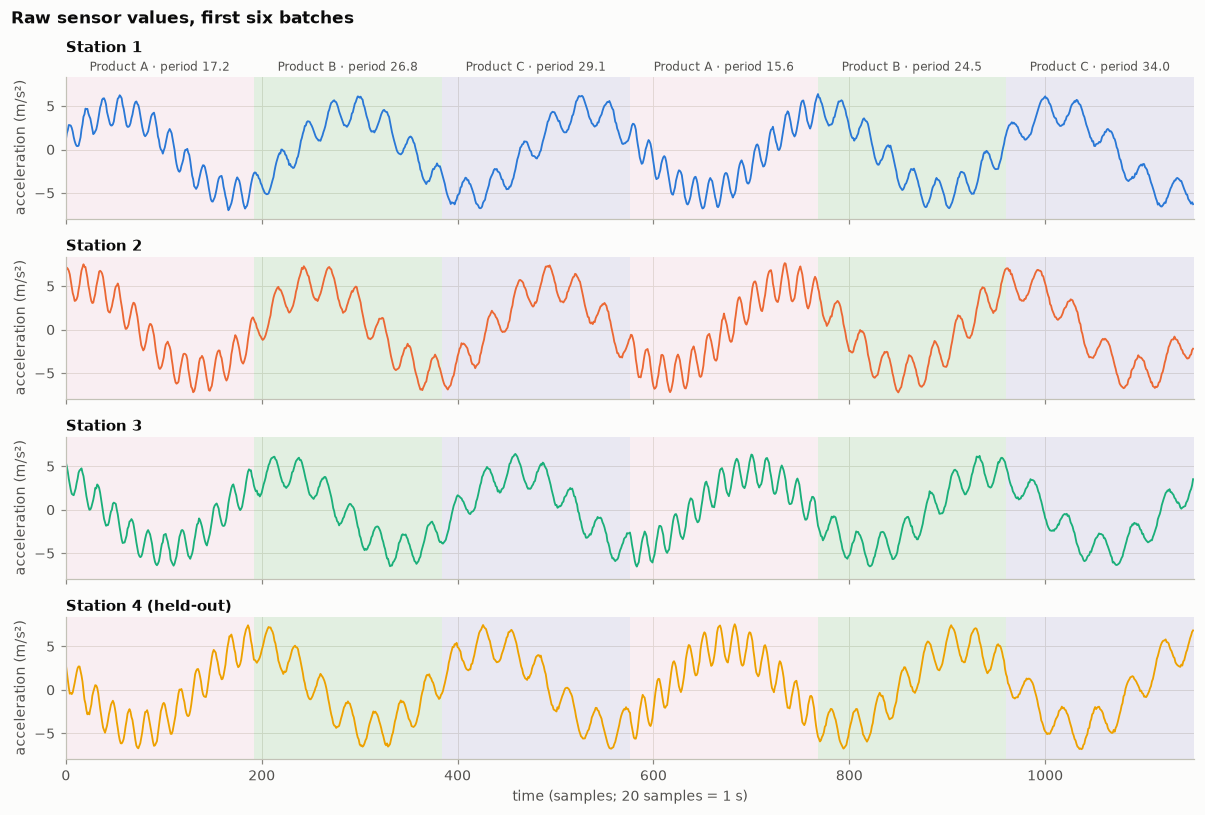

In [3]:
start, stop = 0, 6 * spec.regime_duration
t = np.arange(start, stop)
fig, axes = plt.subplots(4, 1, figsize=(11, 7.5), sharex=True, sharey=True)
for i, ax in enumerate(axes):
    shade_products(ax, start, stop, label=(i == 0))
    ax.plot(t, world.values[i, start:stop], color=STATION[i], lw=1.2)
    ax.set_title(STATION_NAMES[i], pad=16 if i == 0 else 4)
    ax.set_ylabel("acceleration (m/s²)")
axes[-1].set_xlabel("time (samples; 20 samples = 1 s)")
fig.suptitle("Raw sensor values, first six batches", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()

## 2. The three ingredients

`values = slow + seasonal + noise` — the generator keeps each part, so we can plot them separately.

- **slow**: calibration offset + a large sine with a 240-sample period. It ignores products.
- **seasonal**: the vibration. Its period changes at every changeover, but the phase carries on
  smoothly (the shaft does not restart).
- **noise**: Gaussian, sigma 0.09 — tiny next to the other two.

All four panels share one y-axis so the relative sizes are honest.

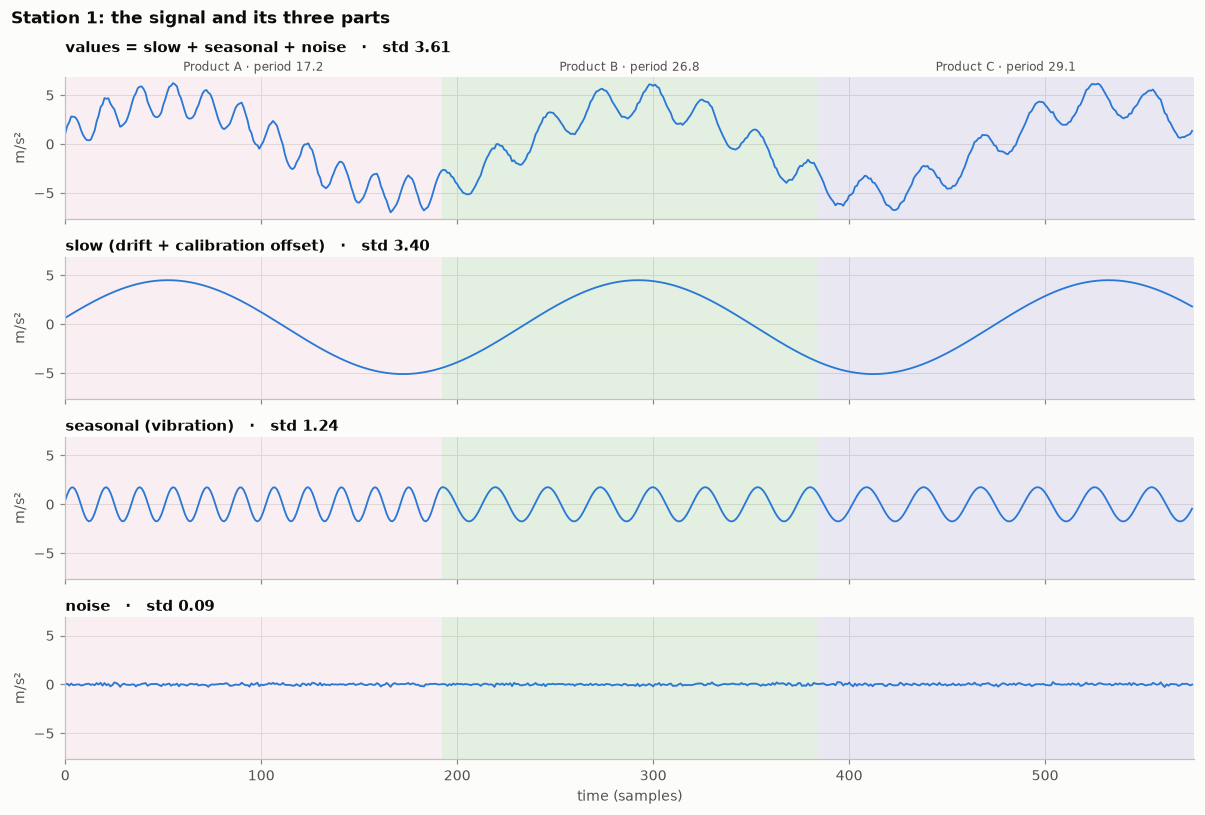

In [4]:
start, stop, station = 0, 3 * spec.regime_duration, 0
t = np.arange(start, stop)
parts = [("values = slow + seasonal + noise", world.values),
         ("slow (drift + calibration offset)", world.slow),
         ("seasonal (vibration)", world.seasonal),
         ("noise", world.noise)]
fig, axes = plt.subplots(4, 1, figsize=(11, 7.5), sharex=True, sharey=True)
for k, (ax, (name, array)) in enumerate(zip(axes, parts)):
    shade_products(ax, start, stop, label=(k == 0))
    series = array[station, start:stop]
    ax.plot(t, series, color=STATION[station], lw=1.2)
    ax.set_title(f"{name}   ·   std {series.std():.2f}", pad=16 if k == 0 else 4)
    ax.set_ylabel("m/s²")
axes[-1].set_xlabel("time (samples)")
fig.suptitle(f"{STATION_NAMES[station]}: the signal and its three parts", x=0.01, ha="left",
             fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Products — How A, B and C can effect data


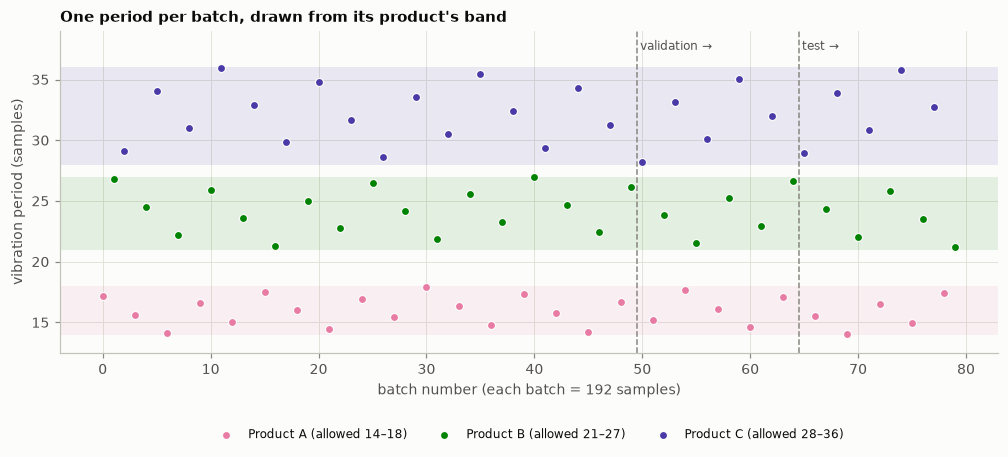

In [5]:
batches = np.arange(len(world.product_index))
periods = world.primary_periods[0]
fig, ax = plt.subplots(figsize=(11, 3.8))
for p, (lo, hi) in enumerate(world.product_period_bands):
    ax.axhspan(lo, hi, color=PRODUCT[p], alpha=0.10, lw=0)
    chosen = world.product_index == p
    ax.scatter(batches[chosen], periods[chosen], s=28, color=PRODUCT[p], edgecolor=SURFACE,
               linewidth=0.8, label=f"{spec.product_names[p]} (allowed {lo:g}–{hi:g})", zorder=3)
for boundary, name in ((data.TRAIN[1], "validation →"), (data.VALIDATION[1], "test →")):
    ax.axvline(boundary / spec.regime_duration - 0.5, color=MUTED, lw=1, ls="--")
    ax.text(boundary / spec.regime_duration - 0.2, 37.2, name, color=INK2, fontsize=8, va="bottom")
ax.set_ylim(12.5, 39)
ax.set_xlabel("batch number (each batch = 192 samples)")
ax.set_ylabel("vibration period (samples)")
ax.set_title("One period per batch, drawn from its product's band")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.show()

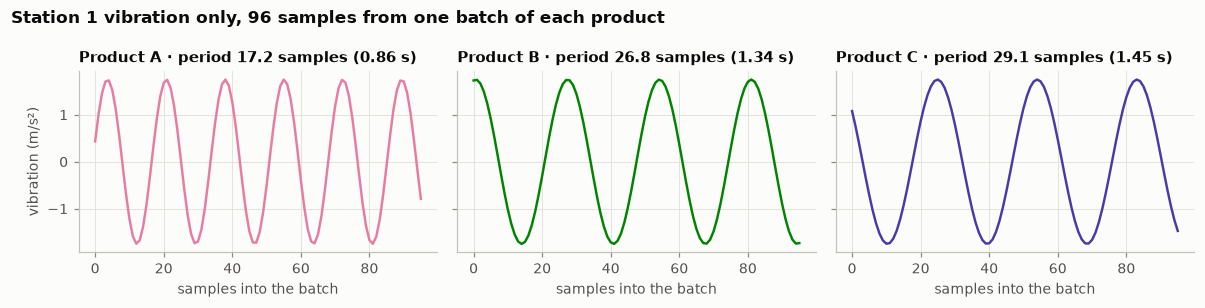

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
for p, ax in enumerate(axes):
    regime = int(np.flatnonzero(world.product_index == p)[0])
    lo = world.regime_boundaries[regime]
    ax.plot(np.arange(96), world.seasonal[0, lo:lo + 96], color=PRODUCT[p])
    period = world.primary_periods[0, regime]
    ax.set_title(f"{spec.product_names[p]} · period {period:.1f} samples "
                 f"({period / data.SAMPLING_RATE_HZ:.2f} s)")
    ax.set_xlabel("samples into the batch")
axes[0].set_ylabel("vibration (m/s²)")
fig.suptitle("Station 1 vibration only, 96 samples from one batch of each product",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Stations — what differs between the four sensors

The stations share the product schedule and the period. They differ only in fixed
mounting/calibration details: vibration amplitude, mounting phase, calibration offset, and the
drift's amplitude and phase. Station 4 is the **held-out** station: it is never used to fit a model
or compute a scaling statistic.

,vibration amplitude,mounting phase (rad),calibration offset,drift amplitude,drift phase (rad)
station,,,,,
Station 1,1.75,0.25,-0.30,4.80,0.20
Station 2,2.05,1.10,0.15,5.25,1.15
Station 3,1.85,2.15,-0.10,4.55,2.05
Station 4 (held-out),2.15,2.85,0.35,5.00,2.75


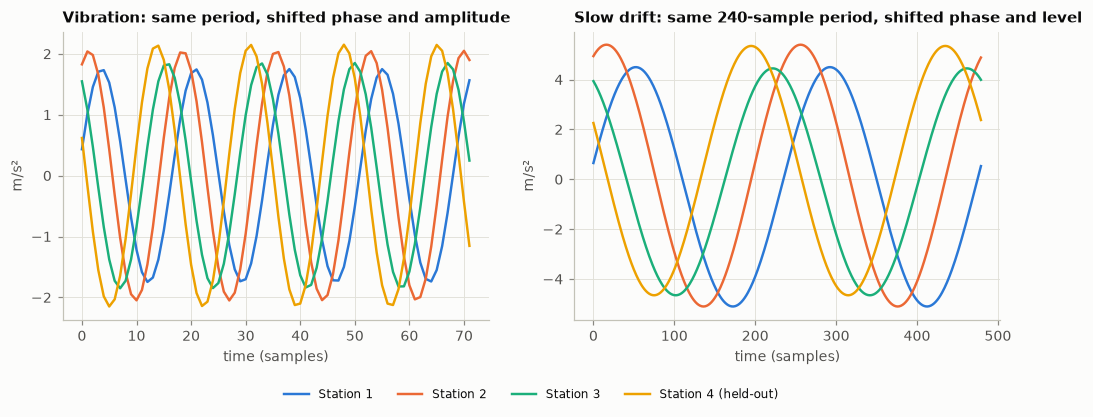

In [7]:
display(pd.DataFrame({
    "station": STATION_NAMES,
    "vibration amplitude": spec.vibration_amplitudes,
    "mounting phase (rad)": spec.mounting_phases,
    "calibration offset": spec.calibration_offsets,
    "drift amplitude": spec.drift_amplitudes,
    "drift phase (rad)": spec.drift_phases,
}).set_index("station"))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for i in range(spec.n_sensors):
    axes[0].plot(np.arange(72), world.seasonal[i, :72], color=STATION[i], label=STATION_NAMES[i])
    axes[1].plot(np.arange(480), world.slow[i, :480], color=STATION[i], label=STATION_NAMES[i])
axes[0].set_title("Vibration: same period, shifted phase and amplitude")
axes[1].set_title("Slow drift: same 240-sample period, shifted phase and level")
for ax in axes:
    ax.set_xlabel("time (samples)")
    ax.set_ylabel("m/s²")
axes[0].legend(loc="upper center", bbox_to_anchor=(1.1, -0.2), ncol=4)
plt.show()

## 5. Splits, windows and eligible forecast origins

The series is cut in time order: **train** 0–9,600, **validation** 9,600–12,480, **test**
12,480–15,360.

A forecasting example is a window: 96 samples of **context** in, the next 48 samples (**horizon**)
out.

,samples,batches,candidate origins,eligible origins,eligible share
split,,,,,
train,0–9600,50,9457,2450,26%
validation,9600–12480,15,2833,735,26%
test,12480–15360,15,2833,735,26%


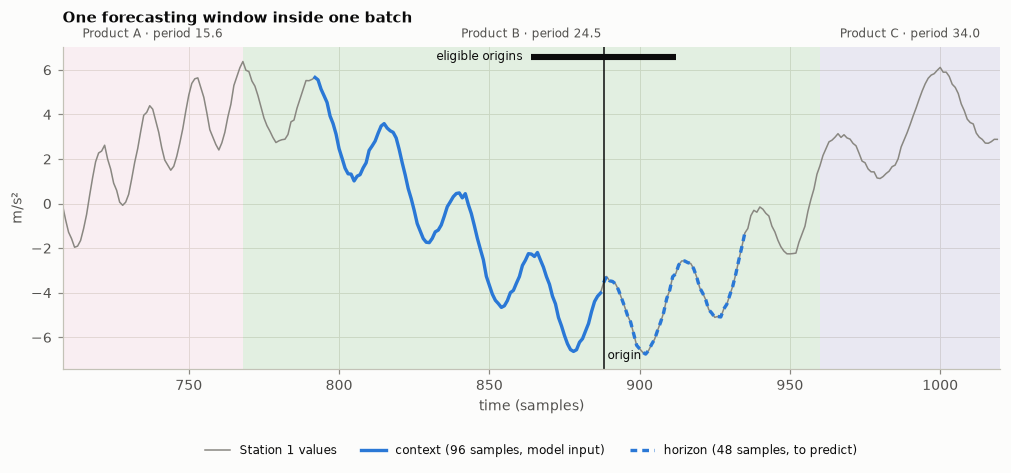

In [8]:
rows = []
for name, region in (("train", data.TRAIN), ("validation", data.VALIDATION), ("test", data.TEST)):
    every = data.origins(region)
    kept = data.origins(region, eligible=world.eligible_origin_mask)
    rows.append({"split": name, "samples": f"{region[0]}–{region[1]}",
                 "batches": (region[1] - region[0]) // spec.regime_duration,
                 "candidate origins": len(every), "eligible origins": len(kept),
                 "eligible share": f"{len(kept) / len(every):.0%}"})
display(pd.DataFrame(rows).set_index("split"))

regime = 4
lo, hi = world.regime_boundaries[regime], world.regime_boundaries[regime + 1]
pad = 60
t = np.arange(lo - pad, hi + pad)
origin = lo + 120
fig, ax = plt.subplots(figsize=(11, 3.8))
shade_products(ax, lo - pad, hi + pad)
ax.plot(t, world.values[0, t], color=MUTED, lw=1, label="Station 1 values")
context_t = np.arange(origin - data.CONTEXT, origin)
target_t = np.arange(origin, origin + data.HORIZON)
ax.plot(context_t, world.values[0, context_t], color=STATION[0], lw=2.2, label="context (96 samples, model input)")
ax.plot(target_t, world.values[0, target_t], color=STATION[0], lw=2.2, ls=(0, (2, 1.5)),
        label="horizon (48 samples, to predict)")
ax.axvline(origin, color=INK, lw=1)
ax.text(origin, 0.03, " origin", transform=ax.get_xaxis_transform(), color=INK, fontsize=8)
eligible = np.flatnonzero(world.eligible_origin_mask[lo:hi]) + lo
ax.plot([eligible[0], eligible[-1]], [0.97, 0.97], transform=ax.get_xaxis_transform(),
        color=INK, lw=4, solid_capstyle="butt")
ax.text(eligible[0] - 3, 0.97, "eligible origins", transform=ax.get_xaxis_transform(),
        ha="right", va="center", color=INK, fontsize=8)
ax.set_title("One forecasting window inside one batch", pad=16)
ax.set_xlabel("time (samples)")
ax.set_ylabel("m/s²")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.show()

## 6. Why detrending matters for reading the period

To forecast well, a model must work out the current batch's period from the 96-sample context.
`data.dense_period_scores` scores every candidate period by how strongly a sinusoid of that
period projects onto the context.

On the **raw** context the big slow drift leaks into the scores and pulls the peak away from the
truth. After subtracting a moving average (**detrended**) the peak sits on the true period. This is
the idea behind the series-decomposition block you implement in the assignment.

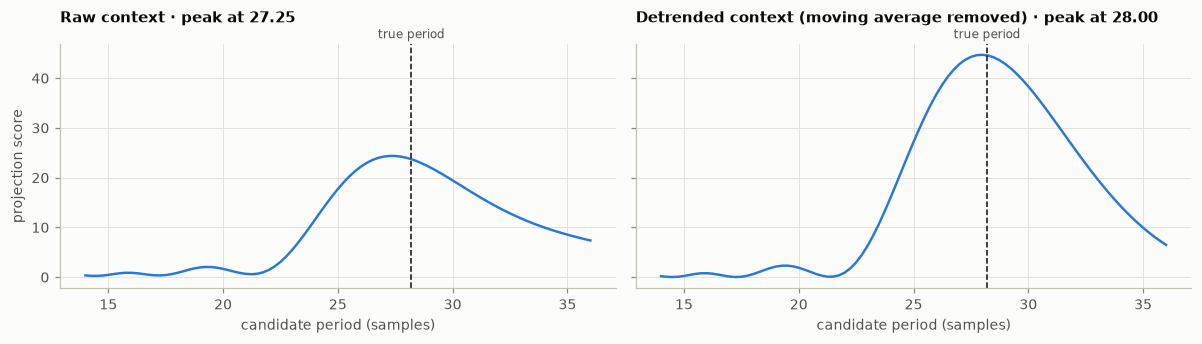

In [9]:
origins = data.origins(data.VALIDATION, stride=4, eligible=world.eligible_origin_mask)
context, target = data.windows(world.values, origins)          # [stations, windows, 96]
true_period, product = data.window_regime_values(world, origins)

example = int(np.flatnonzero(product == 2)[0])                  # one Product C window
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, kernel, name in zip(axes, (0, 25), ("Raw context", "Detrended context (moving average removed)")):
    grid, scores = data.dense_period_scores(context[0, example], detrend_kernel=kernel)
    ax.plot(grid, scores, color=STATION[0])
    ax.axvline(true_period[0, example], color=INK, lw=1, ls="--")
    ax.text(true_period[0, example], 1.01, "true period", transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", color=INK2, fontsize=8)
    ax.set_title(f"{name} · peak at {grid[scores.argmax()]:.2f}", pad=14)
    ax.set_xlabel("candidate period (samples)")
axes[0].set_ylabel("projection score")
fig.tight_layout()
plt.show()

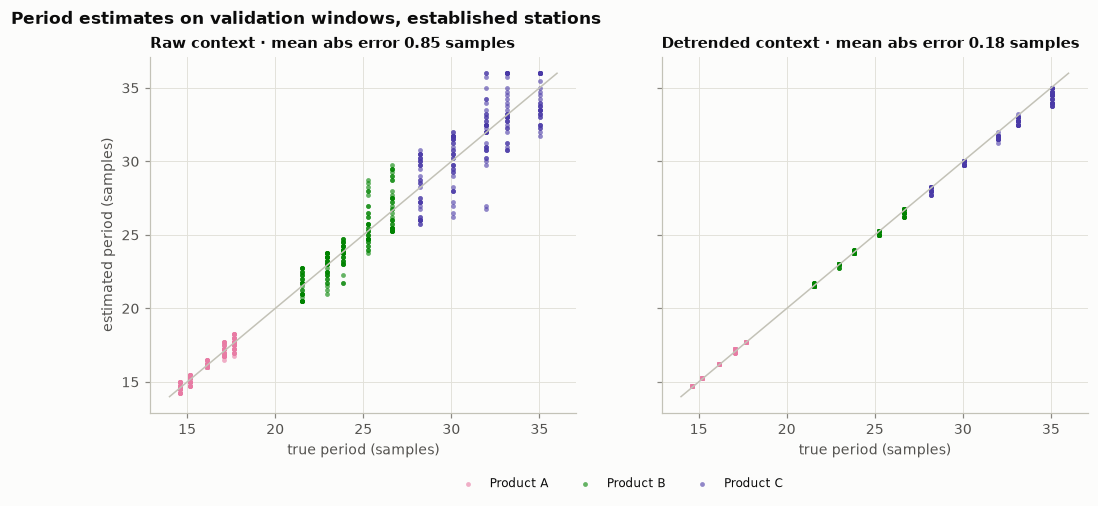

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
lo, hi = data.PERIOD_SEARCH_RANGE
for ax, kernel, name in zip(axes, (0, 25), ("Raw context", "Detrended context")):
    estimate = data.estimate_period(context[world.established], detrend_kernel=kernel)
    truth = true_period[world.established]
    ax.plot([lo, hi], [lo, hi], color=AXIS, lw=1)
    for p in range(3):
        chosen = np.broadcast_to(product == p, truth.shape)
        ax.scatter(truth[chosen], estimate[chosen], s=10, color=PRODUCT[p], alpha=0.6,
                   linewidth=0, label=spec.product_names[p])
    ax.set_title(f"{name} · mean abs error {np.abs(estimate - truth).mean():.2f} samples")
    ax.set_xlabel("true period (samples)")
axes[0].set_ylabel("estimated period (samples)")
axes[0].legend(loc="upper center", bbox_to_anchor=(1.1, -0.15), ncol=3)
fig.suptitle("Period estimates on validation windows, established stations",
             x=0.01, ha="left", fontweight="bold")
plt.show()

## Save the generated data to disk

The harness never writes the series itself. This cell writes it to `task1_world_seed0.csv` beside the notebook
(set `SAVE = False` to skip).

In [11]:
SAVE = True
if SAVE:
    frame = pd.DataFrame(world.values.T, columns=[f"station_{i + 1}" for i in range(spec.n_sensors)])
    frame.insert(0, "sample", np.arange(spec.length))
    frame["batch"] = world.regime_index
    frame["product"] = np.asarray(spec.product_names)[world.product_index[world.regime_index]]
    frame["period"] = world.primary_periods[0, world.regime_index]
    frame.to_csv("task1_world_seed0.csv", index=False)
    print("wrote task1_world_seed0.csv", frame.shape)

wrote task1_world_seed0.csv (15360, 8)
